#### **Electricity Consumption Prediction**
**Dataset:** UCI Individual Household Electric Power Consumption  
**Objective:** Predict the next-hour average household active power consumption (kW) using historical electricity measurements and engineered time-series features.

##### **1. Workflow**
Raw data → cleaning → timestamp creation → hourly aggregation → feature engineering → chronological train/test split → Linear/Ridge/Lasso → evaluation → model saving.
Because this is time-series data, the notebook does not randomly shuffle observations before testing.

In [8]:
import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
DATA_PATH = "household_power_consumption.txt"
print("Ready")

Ready


##### 2. **Load the UCI dataset**

In [9]:
df = pd.read_csv(DATA_PATH, sep=";", na_values="?", low_memory=False)
print("Shape:", df.shape)
display(df.head())
print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False))

Shape: (2075259, 9)


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0



Missing values:


Global_active_power      25979
Sub_metering_2           25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_3           25979
Sub_metering_1           25979
Date                         0
Time                         0
dtype: int64

##### **3. Clean the data**

In [10]:
numeric_cols = ["Global_active_power","Global_reactive_power","Voltage","Global_intensity","Sub_metering_1","Sub_metering_2","Sub_metering_3"]
for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["timestamp"] = pd.to_datetime(df["Date"].astype(str)+" "+df["Time"].astype(str), dayfirst=True, errors="coerce")
df = df.dropna(subset=["timestamp"]).sort_values("timestamp")
df = df.drop_duplicates(subset=["timestamp"], keep="first").set_index("timestamp")
df = df.drop(columns=["Date","Time"])
df[numeric_cols] = df[numeric_cols].interpolate(method="time").ffill().bfill()
print("Cleaned shape:", df.shape)
print("Remaining missing:", int(df.isna().sum().sum()))

Cleaned shape: (2075259, 7)
Remaining missing: 0


##### **4. Hourly aggregation**

In [11]:
hourly = df[numeric_cols].resample("h").mean().dropna()
print("Hourly shape:", hourly.shape)
print("Period:", hourly.index.min(), "to", hourly.index.max())
display(hourly.head())

Hourly shape: (34589, 7)
Period: 2006-12-16 17:00:00 to 2010-11-26 21:00:00


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
timestamp,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667


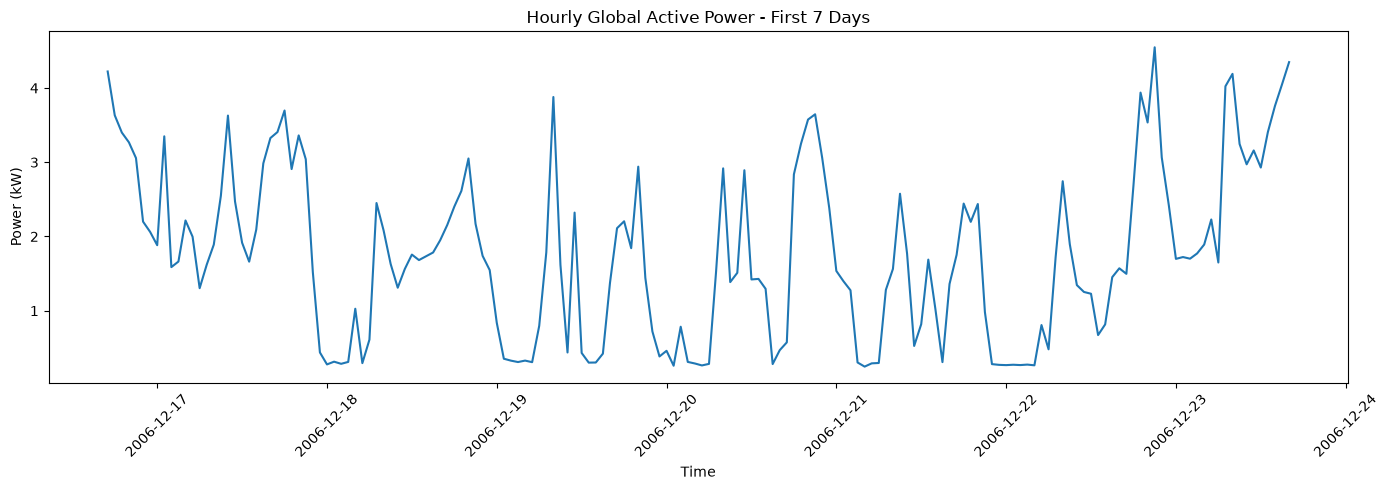

In [12]:
plt.figure(figsize=(14,5))
plt.plot(hourly.iloc[:24*7].index, hourly.iloc[:24*7]["Global_active_power"])
plt.title("Hourly Global Active Power - First 7 Days")
plt.xlabel("Time"); plt.ylabel("Power (kW)")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

##### 5. **Feature engineering**

Calendar features, cyclical time features, lag features and rolling averages are created. The target is the next hour’s average `Global_active_power`.

In [13]:
data = hourly.copy()
data["hour"] = data.index.hour
data["day_of_week"] = data.index.dayofweek
data["month"] = data.index.month
data["is_weekend"] = (data["day_of_week"] >= 5).astype(int)
data["hour_sin"] = np.sin(2*np.pi*data["hour"]/24)
data["hour_cos"] = np.cos(2*np.pi*data["hour"]/24)
data["dow_sin"] = np.sin(2*np.pi*data["day_of_week"]/7)
data["dow_cos"] = np.cos(2*np.pi*data["day_of_week"]/7)
for lag in [1,2,3,24,48,168]:
    data[f"power_lag_{lag}h"] = data["Global_active_power"].shift(lag)
data["rolling_mean_3h"] = data["Global_active_power"].shift(1).rolling(3).mean()
data["rolling_mean_24h"] = data["Global_active_power"].shift(1).rolling(24).mean()
data["rolling_mean_7d"] = data["Global_active_power"].shift(1).rolling(168).mean()
data["target_next_hour"] = data["Global_active_power"].shift(-1)
model_data = data.dropna().copy()
print("Model-ready shape:", model_data.shape)

Model-ready shape: (34420, 25)


In [14]:
display(model_data.select_dtypes(include=np.number).corr()["target_next_hour"].sort_values(ascending=False).to_frame("correlation"))

,correlation
target_next_hour,1.000000
Global_intensity,0.713606
Global_active_power,0.713432
power_lag_1h,0.465615
Sub_metering_3,0.456570
power_lag_168h,0.392707
power_lag_24h,0.383602
rolling_mean_3h,0.347183
power_lag_48h,0.345193
rolling_mean_24h,0.327701


##### **6. Chronological train/test split**

In [15]:
feature_cols = ["Global_active_power","Global_reactive_power","Voltage","Global_intensity","Sub_metering_1","Sub_metering_2","Sub_metering_3","hour","day_of_week","month","is_weekend","hour_sin","hour_cos","dow_sin","dow_cos","power_lag_1h","power_lag_2h","power_lag_3h","power_lag_24h","power_lag_48h","power_lag_168h","rolling_mean_3h","rolling_mean_24h","rolling_mean_7d"]
X = model_data[feature_cols]
y = model_data["target_next_hour"]
split = int(len(model_data)*0.80)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]
print("Train:", len(X_train), "Test:", len(X_test))
print("Train period:", X_train.index.min(), "to", X_train.index.max())
print("Test period:", X_test.index.min(), "to", X_test.index.max())

Train: 27536 Test: 6884
Train period: 2006-12-23 17:00:00 to 2010-02-13 00:00:00
Test period: 2010-02-13 01:00:00 to 2010-11-26 20:00:00


##### **7. Train and compare models**

In [16]:
models = {
    "Linear Regression": Pipeline([("scaler",StandardScaler()),("model",LinearRegression())]),
    "Ridge Regression": Pipeline([("scaler",StandardScaler()),("model",Ridge(alpha=1.0))]),
    "Lasso Regression": Pipeline([("scaler",StandardScaler()),("model",Lasso(alpha=0.001,max_iter=10000))])
}
rows=[]
for name, model in models.items():
    model.fit(X_train,y_train)
    pred=model.predict(X_test)
    rows.append({"Model":name,"MAE":mean_absolute_error(y_test,pred),"RMSE":np.sqrt(mean_squared_error(y_test,pred)),"R2":r2_score(y_test,pred)})
results_df=pd.DataFrame(rows).sort_values("RMSE").reset_index(drop=True)
display(results_df)
best_name=results_df.loc[0,"Model"]
best_model=models[best_name]
best_pred=best_model.predict(X_test)
print("Best by RMSE:",best_name)

,Model,MAE,RMSE,R2
0,Lasso Regression,0.369743,0.515559,0.498615
1,Ridge Regression,0.370176,0.515811,0.498124
2,Linear Regression,0.370188,0.515815,0.498117


Best by RMSE: Lasso Regression


##### **8. Actual vs predicted**

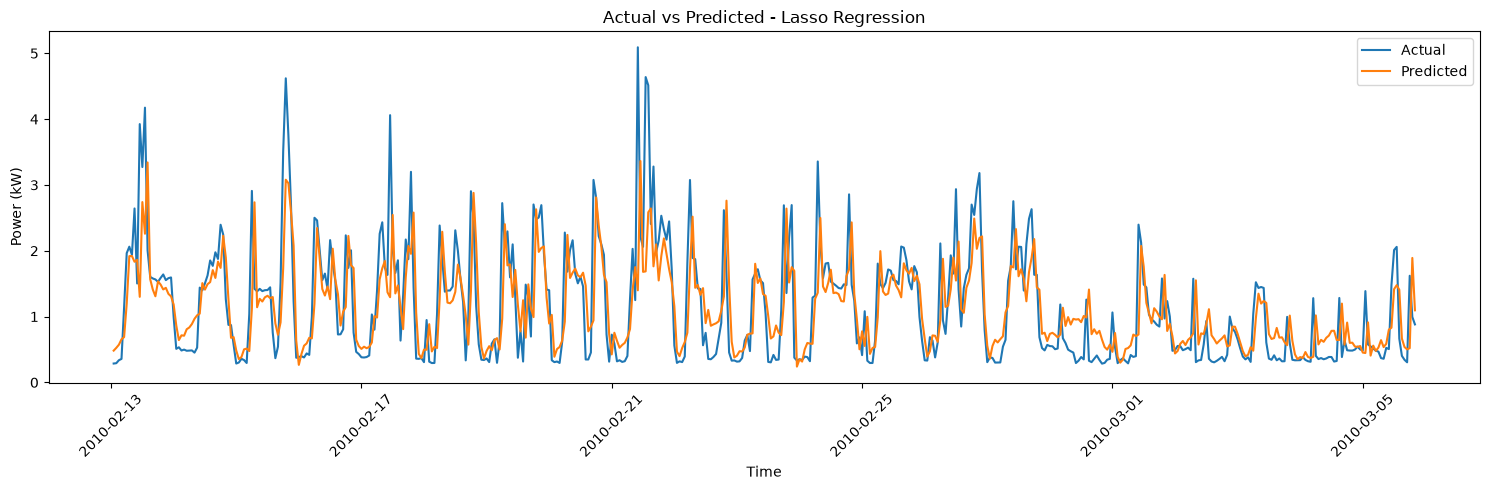

In [17]:
n=min(500,len(y_test))
plt.figure(figsize=(15,5))
plt.plot(y_test.iloc[:n].index,y_test.iloc[:n],label="Actual")
plt.plot(y_test.iloc[:n].index,best_pred[:n],label="Predicted")
plt.title(f"Actual vs Predicted - {best_name}")
plt.xlabel("Time"); plt.ylabel("Power (kW)"); plt.legend(); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

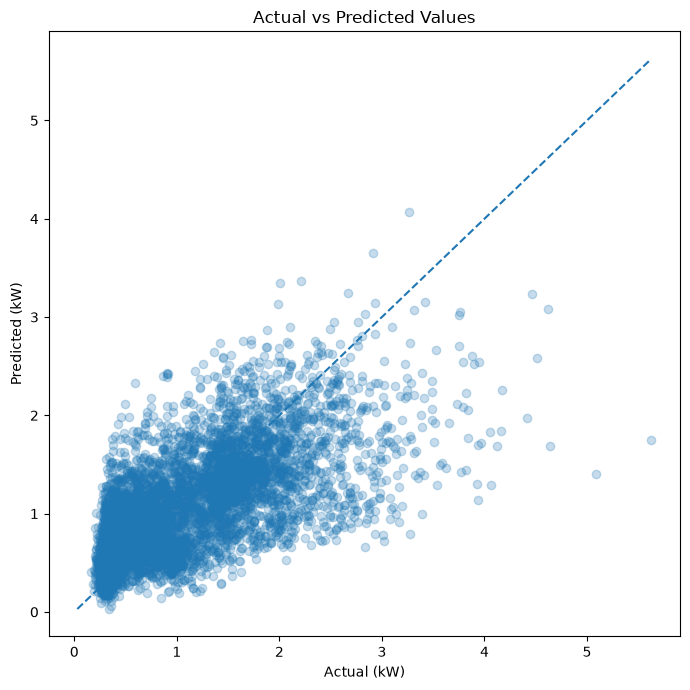

In [18]:
plt.figure(figsize=(7,7))
plt.scatter(y_test,best_pred,alpha=0.25)
lo=min(y_test.min(),best_pred.min()); hi=max(y_test.max(),best_pred.max())
plt.plot([lo,hi],[lo,hi],linestyle="--")
plt.xlabel("Actual (kW)"); plt.ylabel("Predicted (kW)"); plt.title("Actual vs Predicted Values"); plt.tight_layout(); plt.show()

##### **9. Model coefficients**

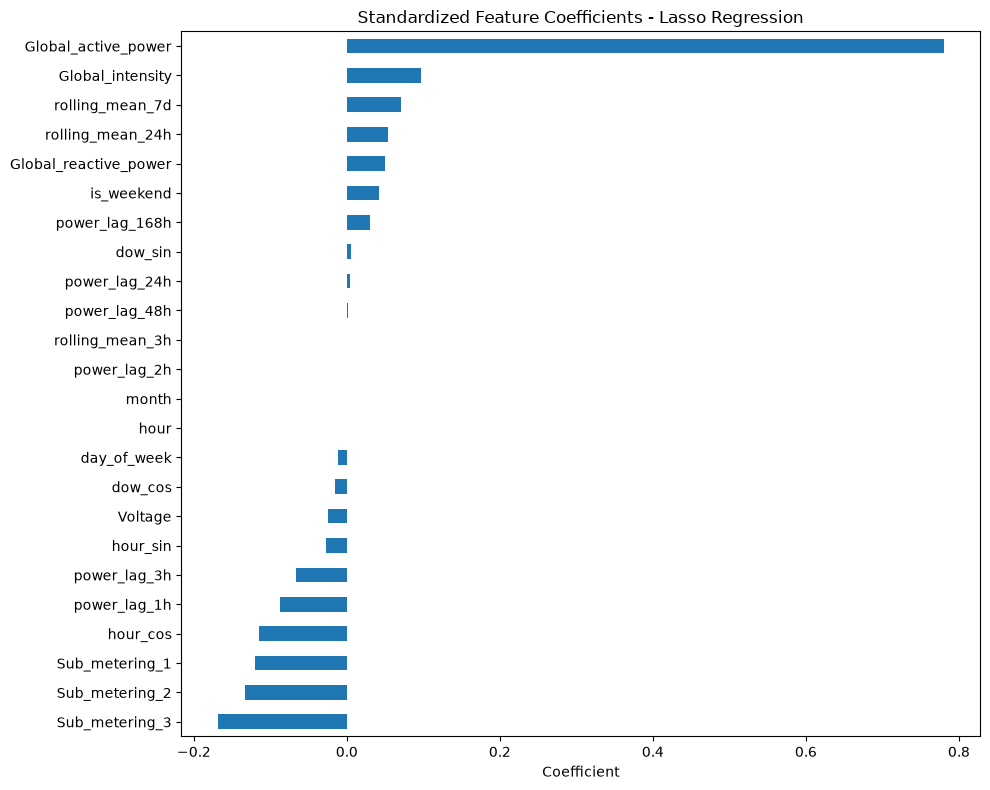

,coefficient
Sub_metering_3,-0.168747
Sub_metering_2,-0.132756
Sub_metering_1,-0.120519
hour_cos,-0.114218
power_lag_1h,-0.086908
power_lag_3h,-0.067001
hour_sin,-0.026570
Voltage,-0.024015
dow_cos,-0.015429
day_of_week,-0.011644


In [19]:
coefs=pd.Series(best_model.named_steps["model"].coef_,index=feature_cols).sort_values()
plt.figure(figsize=(10,8)); coefs.plot(kind="barh"); plt.title(f"Standardized Feature Coefficients - {best_name}"); plt.xlabel("Coefficient"); plt.tight_layout(); plt.show()
display(coefs.to_frame("coefficient"))

##### **10. Save model artifact**

In [20]:
os.makedirs("models",exist_ok=True)
artifact={"model":best_model,"feature_cols":feature_cols,"target":"target_next_hour","model_name":best_name}
joblib.dump(artifact,"models/electricity_consumption_model.pkl")
print("Saved models/electricity_consumption_model.pkl")

Saved models/electricity_consumption_model.pkl


##### **11. Example prediction**

In [21]:
latest_features=X.iloc[[-1]]
prediction=best_model.predict(latest_features)[0]
print(f"Predicted next-hour average active power: {prediction:.3f} kW")

Predicted next-hour average active power: 1.199 kW
